# CS 559 Final Project — Phase 1 (Team Notebook)

**Bankruptcy Prediction.** This notebook covers the team-level work:
- **Section 3.1** — preprocess training data, save pipeline
- **Section 3.2** — cluster companies into k=8 subgroups
- **Section 3.3.1** — train classifier to route new companies to clusters

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings('ignore')

# fix seed so results are reproducible (spec requires this)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'joblib version: {joblib.__version__}  (team should match)')

joblib version: 1.5.3  (team should match)


## Load Data

In [2]:
df = pd.read_csv('train_data.csv')
df.columns = df.columns.str.strip()  # some columns have leading spaces
print(f'Shape: {df.shape}')
df.head(3)

Shape: (5807, 97)


,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.450397,0.504034,0.506986,0.594640,0.594640,0.998906,0.797293,0.809239,...,0.780554,0.004919,0.623634,0.594641,0.838869,0.279036,0.026788,0.565144,1,0.032464
1,1,0,0.530005,0.572885,0.574763,0.605695,0.605558,0.999058,0.797512,0.809399,...,0.819963,0.005968,0.624171,0.605690,0.841869,0.279040,0.026801,0.565205,1,0.032442
2,2,0,0.571150,0.620148,0.624177,0.612275,0.612282,0.999163,0.797654,0.809533,...,0.839128,0.006022,0.625306,0.612271,0.843294,0.278927,0.026816,0.565276,1,0.033034


In [3]:
# split into target, index, features
y   = df['Bankrupt?'].copy()
idx = df['Index'].copy()
X   = df.drop(columns=['Index', 'Bankrupt?'])

# drop the one zero-variance feature (Net Income Flag is 1 for everyone)
zero_var_cols = X.var()[X.var() < 1e-6].index.tolist()
print(f'Zero-variance features to drop: {zero_var_cols}')
X = X.drop(columns=zero_var_cols)

print(f'\nFeatures X: {X.shape}')
print(f'Target y:   {y.shape}')
print(f'Missing values: {X.isnull().sum().sum()}')

Zero-variance features to drop: ['Net Income Flag']

Features X: (5807, 94)
Target y:   (5807,)
Missing values: 0


## Exploratory Data Analysis

### Target distribution

This is the imbalance we have to deal with.

In [4]:
counts = y.value_counts()
prop = y.value_counts(normalize=True)

print("\nTARGET DISTRIBUTION")
print(f"Not Bankrupt (y=0): {counts[0]:>5} ({prop[0]*100:5.2f}%)")
print(f"Bankrupt     (y=1): {counts[1]:>5} ({prop[1]*100:5.2f}%)")
print(f"Imbalance ratio:   1 bankrupt for every {counts[0]/counts[1]:.1f} healthy firms")
print(f"Total companies:   {len(y)}")


TARGET DISTRIBUTION
Not Bankrupt (y=0):  5609 (96.59%)
Bankrupt     (y=1):   198 ( 3.41%)
Imbalance ratio:   1 bankrupt for every 28.3 healthy firms
Total companies:   5807


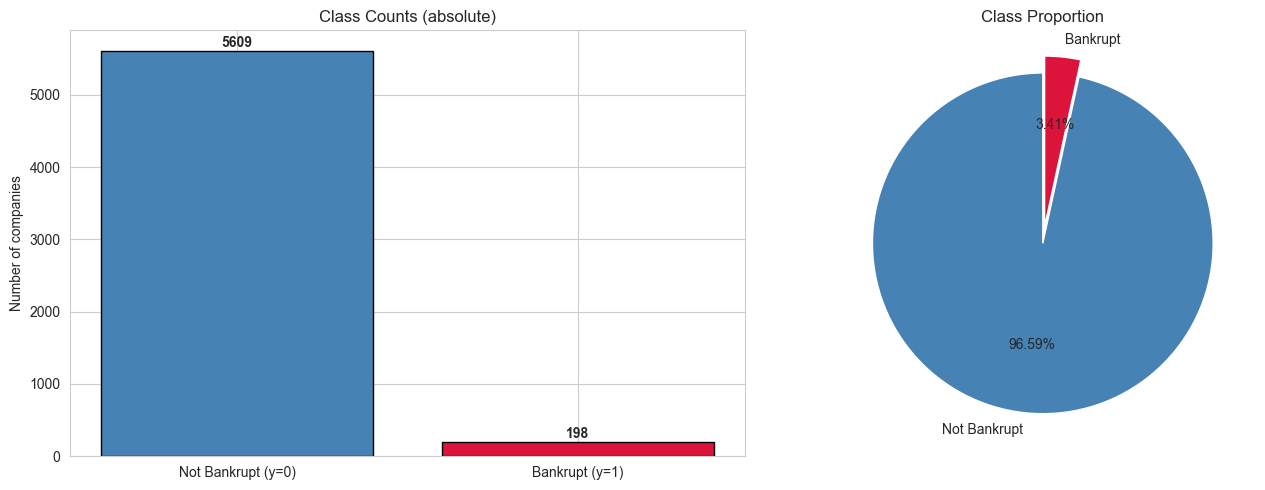

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart with counts
bars = axes[0].bar(['Not Bankrupt (y=0)', 'Bankrupt (y=1)'], counts.values,
                    color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Counts (absolute)')
axes[0].set_ylabel('Number of companies')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, str(v),
                 ha='center', fontweight='bold')

# Pie with proportions
axes[1].pie(counts.values, labels=['Not Bankrupt', 'Bankrupt'],
            autopct='%1.2f%%', colors=['steelblue', 'crimson'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

### Feature scales

Want to see if the features are on similar ranges before clustering. KMeans uses Euclidean distance so scale matters a lot.

In [6]:
# basic stats per feature
scale_summary = pd.DataFrame({
    'min': X.min(),
    'max': X.max(),
    'mean': X.mean(),
    'median': X.median(),
    'std': X.std(),
    'range': X.max() - X.min()
})

# split into normal-range vs extreme features
extreme = scale_summary[(scale_summary['min'] < 0) | (scale_summary['max'] > 1.5)]
normal  = scale_summary[(scale_summary['min'] >= 0) & (scale_summary['max'] <= 1.5)]

print(f"Features in normal range (0 to 1.5):  {len(normal):>2}")
print(f"Features with extreme values:         {len(extreme):>2}")
print(f"Total:                                {len(scale_summary):>2}")

Features in normal range (0 to 1.5):  70
Features with extreme values:         24
Total:                                94


In [7]:
# these are the features with extreme values — they would dominate KMeans without scaling
print("EXTREME-SCALE FEATURES (min, max, range):\n")
extreme_sorted = extreme.sort_values('max', ascending=False)
for feat, row in extreme_sorted.iterrows():
    print(f"  {feat[:48]:<50} max={row['max']:>12.2e}  range={row['range']:>12.2e}")

EXTREME-SCALE FEATURES (min, max, range):

  Cash Turnover Rate                                 max=    1.00e+10  range=    1.00e+10
  Current Asset Turnover Rate                        max=    1.00e+10  range=    1.00e+10
  Quick Asset Turnover Rate                          max=    1.00e+10  range=    1.00e+10
  Operating Expense Rate                             max=    9.99e+09  range=    9.99e+09
  Inventory Turnover Rate (times)                    max=    9.99e+09  range=    9.99e+09
  Total Asset Growth Rate                            max=    9.99e+09  range=    9.99e+09
  Fixed Assets Turnover Frequency                    max=    9.99e+09  range=    9.99e+09
  Research and development expense rate              max=    9.98e+09  range=    9.98e+09
  Total debt/Total net worth                         max=    9.94e+09  range=    9.94e+09
  Inventory/Current Liability                        max=    9.91e+09  range=    9.91e+09
  Total assets to GNP price                          max=

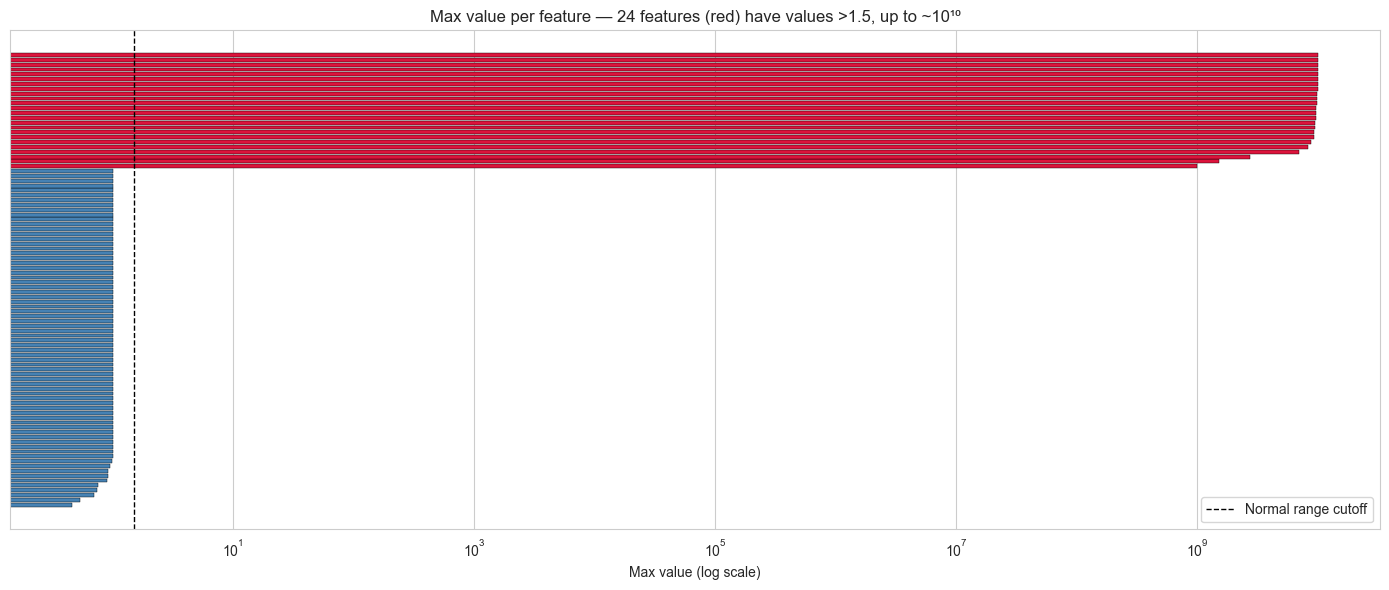

In [8]:
# log-scale the max per feature to show the disparity visually
fig, ax = plt.subplots(figsize=(14, 6))

max_vals = X.max().sort_values()
colors = ['crimson' if v > 1.5 else 'steelblue' for v in max_vals.values]

ax.barh(range(len(max_vals)), max_vals.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xscale('log')
ax.set_yticks([])
ax.set_xlabel('Max value (log scale)')
ax.set_title(f'Max value per feature — {len(extreme)} features (red) have values >1.5, up to ~10¹⁰')
ax.axvline(1.5, color='black', linestyle='--', linewidth=1, label='Normal range cutoff')
ax.legend()
plt.tight_layout()
plt.show()

Some features go up to ~10¹⁰, most are between 0 and 1.5. Definitely need scaling. Plain MinMax won't work either since a couple of huge outliers would squash everything else to near-zero — using PowerTransformer in the pipeline below to handle this properly.

### Skewness

Checking how heavily skewed the features are.

In [9]:
shape_stats = pd.DataFrame({
    'skew': X.skew(),
    'kurtosis': X.kurt(),
    'abs_skew': X.skew().abs()
}).sort_values('abs_skew', ascending=False)

heavy_skew = shape_stats[shape_stats['abs_skew'] > 3]
moderate   = shape_stats[(shape_stats['abs_skew'] > 1) & (shape_stats['abs_skew'] <= 3)]
near_norm  = shape_stats[shape_stats['abs_skew'] <= 1]

print(f"Heavy skew (|skew| > 3):    {len(heavy_skew):>2} features")
print(f"Moderate skew (1 < |s| ≤3): {len(moderate):>2} features")
print(f"Near normal (|skew| ≤ 1):   {len(near_norm):>2} features")

Heavy skew (|skew| > 3):    66 features
Moderate skew (1 < |s| ≤3): 16 features
Near normal (|skew| ≤ 1):   12 features


In [10]:
print("TOP 15 MOST SKEWED FEATURES\n")
print(shape_stats[['skew', 'kurtosis']].head(15).round(2).to_string())

TOP 15 MOST SKEWED FEATURES

                                          skew  kurtosis
Revenue per person                       76.20   5807.00
Current Ratio                            76.20   5807.00
Fixed Assets to Assets                   76.20   5807.00
Total income/Total expense               75.99   5785.61
Net Value Growth Rate                    74.09   5573.57
Contingent liabilities/Net worth         73.88   5565.02
Realized Sales Gross Profit Growth Rate  72.69   5441.02
Operating Profit Growth Rate            -66.29   4853.60
Operating Profit Rate                   -64.96   4450.32
Continuous Net Profit Growth Rate        61.98   4601.34
Total Asset Return Growth Rate Ratio     57.81   4335.54
Quick Assets/Current Liability           54.36   2971.30
After-tax net Interest Rate             -50.51   2710.08
Pre-tax net Interest Rate               -50.35   2761.41
Continuous interest rate (after tax)    -49.53   2697.68


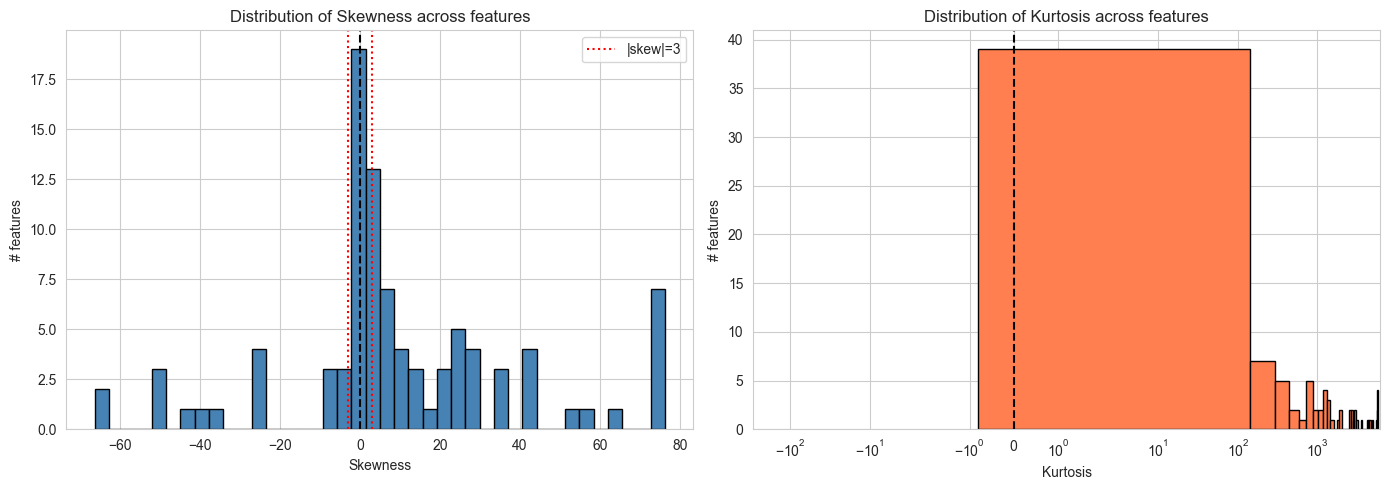

In [11]:
# skewness + kurtosis histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(shape_stats['skew'], bins=40, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].axvline(3, color='red', linestyle=':', label='|skew|=3')
axes[0].axvline(-3, color='red', linestyle=':')
axes[0].set_title('Distribution of Skewness across features')
axes[0].set_xlabel('Skewness')
axes[0].set_ylabel('# features')
axes[0].legend()

axes[1].hist(shape_stats['kurtosis'], bins=40, color='coral', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution of Kurtosis across features')
axes[1].set_xlabel('Kurtosis')
axes[1].set_ylabel('# features')
axes[1].set_xscale('symlog')

plt.tight_layout()
plt.show()

About 2/3 of features are heavily skewed. Yeo-Johnson PowerTransformer will help fix this in the preprocessing pipeline.

### Correlation

Looking for redundant features — if two features are nearly identical we can drop one without losing info.

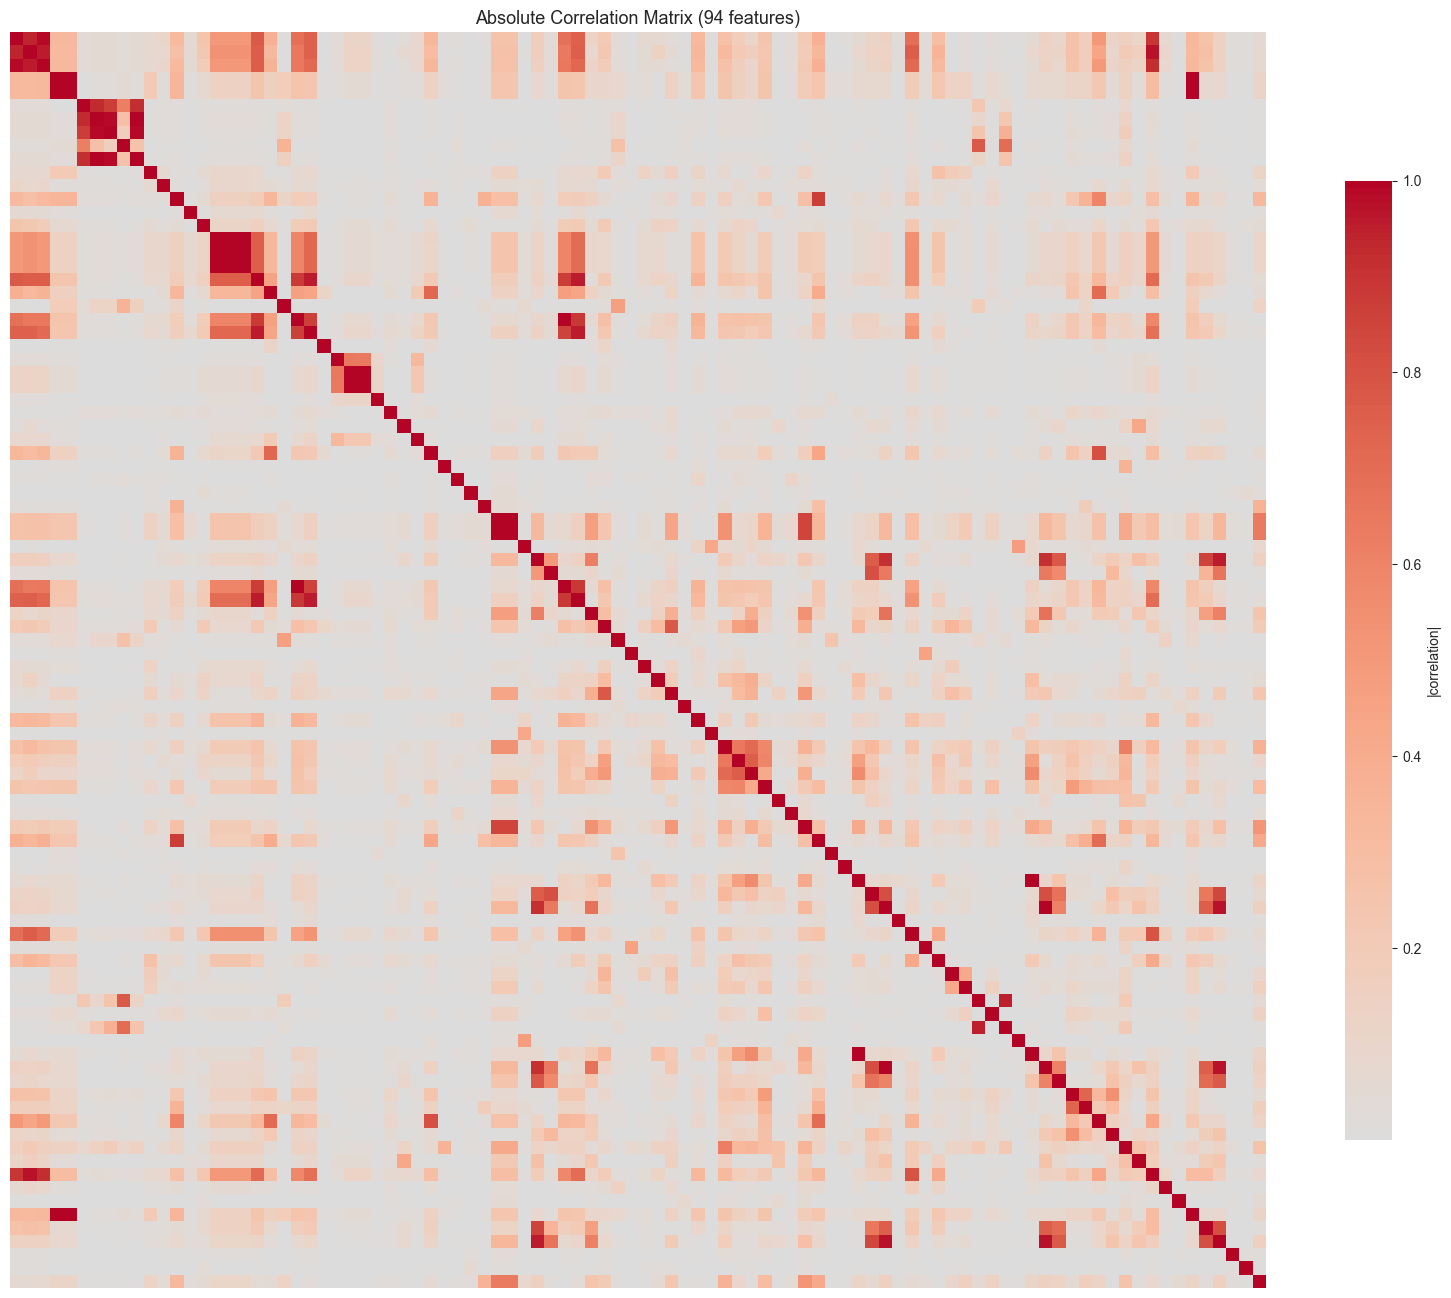

In [12]:
corr = X.corr().abs()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.7, 'label': '|correlation|'},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title(f'Absolute Correlation Matrix ({X.shape[1]} features)', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# find all pairs with |r| > 0.90 from the upper triangle
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pairs = []
for i in range(len(upper.columns)):
    for j in range(i+1, len(upper.columns)):
        val = upper.iloc[i, j]
        if pd.notna(val) and val > 0.90:
            pairs.append((upper.index[i], upper.columns[j], val))

pairs_df = pd.DataFrame(pairs, columns=['Feature A', 'Feature B', '|r|'])
pairs_df = pairs_df.sort_values('|r|', ascending=False).reset_index(drop=True)

print(f"Pairs with |r| > 0.99: {(pairs_df['|r|'] > 0.99).sum()}")
print(f"Pairs with |r| > 0.95: {(pairs_df['|r|'] > 0.95).sum()}")
print(f"Pairs with |r| > 0.90: {(pairs_df['|r|'] > 0.90).sum()}")
print("\nTop 25 highly correlated pairs:")
print(pairs_df.head(25).round(3).to_string())

Pairs with |r| > 0.99: 12
Pairs with |r| > 0.95: 24
Pairs with |r| > 0.90: 30

Top 25 highly correlated pairs:
                                                  Feature A                                          Feature B    |r|
0                             Current Liabilities/Liability                     Current Liability to Liability  1.000
1                                Current Liabilities/Equity                        Current Liability to Equity  1.000
2                                              Debt ratio %                                   Net worth/Assets  1.000
3                                    Operating Gross Margin                              Gross Profit to Sales  1.000
4                                   Net Value Per Share (A)                            Net Value Per Share (C)  1.000
5                                    Operating Gross Margin                        Realized Sales Gross Margin  1.000
6                               Realized Sales Gross Margin    

There are a lot of near-duplicates (e.g. ROA(A), ROA(B), ROA(C) all measuring similar things). Going to drop one feature from each highly-correlated pair.

In [14]:
# from each |r|>0.95 pair, drop the one with lower variance
THRESHOLD = 0.95
to_drop = set()
strong_pairs = pairs_df[pairs_df['|r|'] > THRESHOLD]

for _, row in strong_pairs.iterrows():
    a, b = row['Feature A'], row['Feature B']
    if a in to_drop or b in to_drop:
        continue
    # higher variance = more information
    to_drop.add(a if X[a].var() < X[b].var() else b)

X_pruned = X.drop(columns=list(to_drop))
print(f"Features dropped (|r| > {THRESHOLD}): {len(to_drop)}")
print(f"Remaining features: {X_pruned.shape[1]}\n")
print("Dropped features:")
for f in sorted(to_drop):
    print(f"  - {f}")

Features dropped (|r| > 0.95): 19
Remaining features: 75

Dropped features:
  - After-tax Net Profit Growth Rate
  - Continuous interest rate (after tax)
  - Current Liabilities/Equity
  - Current Liability to Equity
  - Current Liability to Liability
  - Gross Profit to Sales
  - Liability to Equity
  - Net Income to Total Assets
  - Net Value Per Share (A)
  - Net Value Per Share (B)
  - Net profit before tax/Paid-in capital
  - Net worth/Assets
  - Operating profit/Paid-in capital
  - Persistent EPS in the Last Four Seasons
  - Pre-tax net Interest Rate
  - ROA(B) before interest and depreciation after tax
  - ROA(C) before interest and depreciation before interest
  - Realized Sales Gross Margin
  - Working capitcal Turnover Rate


### Class separation

Which features actually discriminate between bankrupt vs healthy? Using Cohen's d (standardized mean difference) and Mann-Whitney U test.

In [15]:
# class-conditional means + Cohen's d + Mann-Whitney p-values
mean_by_class = X_pruned.groupby(y).mean().T
mean_by_class.columns = ['mean_healthy', 'mean_bankrupt']
mean_by_class['mean_diff']     = mean_by_class['mean_bankrupt'] - mean_by_class['mean_healthy']
mean_by_class['abs_mean_diff'] = mean_by_class['mean_diff'].abs()

# Cohen's d: (mean_bankrupt - mean_healthy) / pooled_std
def cohens_d(feature):
    x0 = X_pruned.loc[y==0, feature]
    x1 = X_pruned.loc[y==1, feature]
    pooled_std = np.sqrt((x0.var()*(len(x0)-1) + x1.var()*(len(x1)-1)) / (len(x0)+len(x1)-2))
    if pooled_std == 0:
        return 0.0
    return (x1.mean() - x0.mean()) / pooled_std

mean_by_class['cohens_d']     = [cohens_d(f) for f in mean_by_class.index]
mean_by_class['abs_cohens_d'] = mean_by_class['cohens_d'].abs()

# non-parametric test since features are skewed
pvals = []
for f in mean_by_class.index:
    try:
        _, p = stats.mannwhitneyu(X_pruned.loc[y==0, f], X_pruned.loc[y==1, f],
                                   alternative='two-sided')
    except ValueError:
        p = 1.0
    pvals.append(p)
mean_by_class['mw_pvalue']    = pvals
mean_by_class['neg_log10_p']  = -np.log10(np.maximum(mean_by_class['mw_pvalue'], 1e-300))

class_sep = mean_by_class.sort_values('abs_cohens_d', ascending=False)

print("TOP 20 MOST DISCRIMINATIVE FEATURES (by Cohen's d)\n")
display_cols = ['mean_healthy', 'mean_bankrupt', 'cohens_d', 'mw_pvalue']
print(class_sep[display_cols].head(20).round(4).to_string())

TOP 20 MOST DISCRIMINATIVE FEATURES (by Cohen's d)

                                             mean_healthy  mean_bankrupt  cohens_d  mw_pvalue
ROA(A) before interest and % after tax             0.5623         0.4613   -1.6032        0.0
Debt ratio %                                       0.1105         0.1871    1.4587        0.0
Retained Earnings to Total Assets                  0.9361         0.9062   -1.3933        0.0
Per Share Net profit before tax (Yuan ¥)           0.1858         0.1487   -1.1039        0.0
Working Capital to Total Assets                    0.8159         0.7519   -1.0997        0.0
Current Liability to Assets                        0.0886         0.1430    1.0963        0.0
Borrowing dependency                               0.3740         0.3909    1.0900        0.0
Net Income to Stockholder's Equity                 0.8409         0.8257   -0.9986        0.0
Equity to Long-term Liability                      0.1150         0.1314    0.9767        0.0
Current 

In [16]:
# Bonferroni correction since we're running 75 tests
n_features = X_pruned.shape[1]
alpha = 0.05 / n_features   # Bonferroni correction

significant = class_sep[class_sep['mw_pvalue'] < alpha]
print(f"Features significant at Bonferroni α={alpha:.2e}: {len(significant)} / {n_features}")
print(f"Features with |Cohen's d| > 0.5 (medium effect): {(class_sep['abs_cohens_d'] > 0.5).sum()}")
print(f"Features with |Cohen's d| > 0.8 (large effect):  {(class_sep['abs_cohens_d'] > 0.8).sum()}")

Features significant at Bonferroni α=6.67e-04: 65 / 75
Features with |Cohen's d| > 0.5 (medium effect): 22
Features with |Cohen's d| > 0.8 (large effect):  13


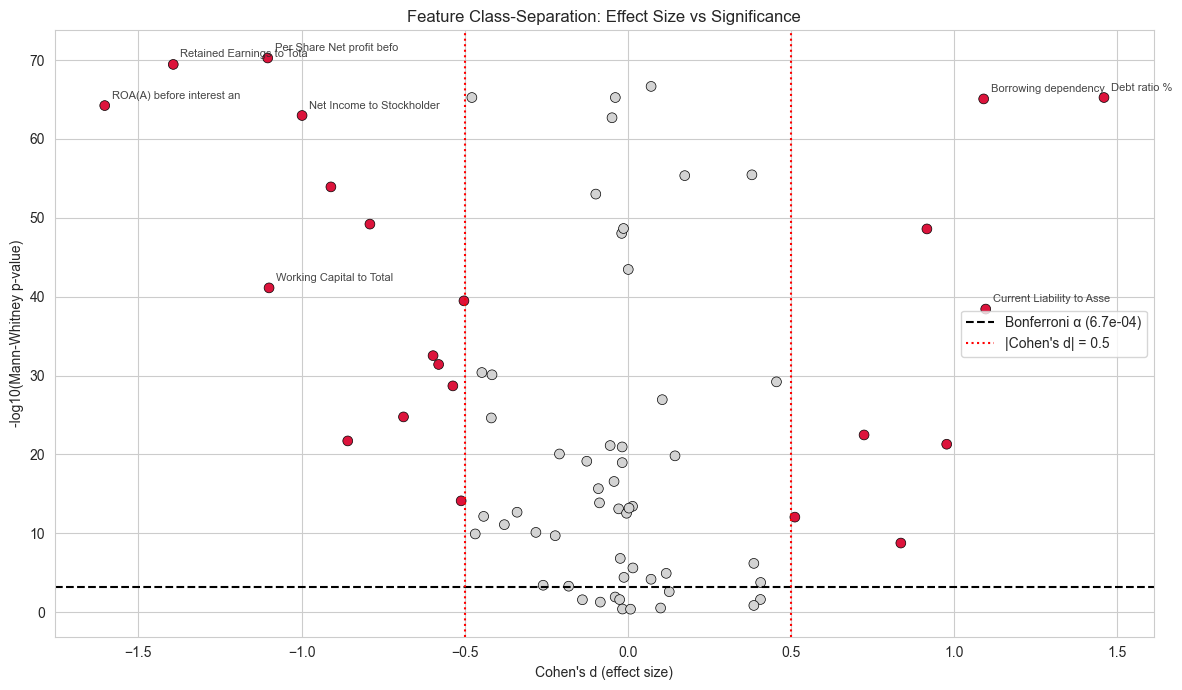

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['crimson' if (abs(d) > 0.5 and p < alpha) else 'lightgray'
          for d, p in zip(class_sep['cohens_d'], class_sep['mw_pvalue'])]

ax.scatter(class_sep['cohens_d'], class_sep['neg_log10_p'],
           c=colors, s=50, edgecolor='black', linewidth=0.5)
ax.axhline(-np.log10(alpha), color='black', linestyle='--',
           label=f'Bonferroni α ({alpha:.1e})')
ax.axvline(0.5, color='red', linestyle=':', label="|Cohen's d| = 0.5")
ax.axvline(-0.5, color='red', linestyle=':')
ax.set_xlabel("Cohen's d (effect size)")
ax.set_ylabel('-log10(Mann-Whitney p-value)')
ax.set_title('Feature Class-Separation: Effect Size vs Significance')
ax.legend()

# Label the top 8 most discriminative
for feat in class_sep.head(8).index:
    ax.annotate(feat[:25], (class_sep.loc[feat, 'cohens_d'],
                             class_sep.loc[feat, 'neg_log10_p']),
                fontsize=8, alpha=0.85,
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Most features are statistically significant and 22 have at least medium-sized effects. Useful to know for Phase 2 when each of us picks features for our individual stacking models.

---
## Section 3.1 — Training Data Preprocessing

Build a preprocessing pipeline that:
1. Drops the zero-variance feature + the highly-correlated ones
2. Applies Yeo-Johnson to fix skew and standardizes
3. Reduces to ≤50 features via PCA (spec cap)

Saving with joblib so the generalization notebook (Phase 4) can apply the exact same transformation to test data.

In [18]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drops specified columns. Used as the first step of the pipeline so test data
    goes through the same column-drop step as training data."""
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=[c for c in self.columns_to_drop if c in X.columns])
        return X

# combine all the columns we want to drop
cols_to_drop = list(zero_var_cols) + list(to_drop)
print(f'Total columns to drop: {len(cols_to_drop)}')
print(f'  zero-variance:   {len(zero_var_cols)}')
print(f'  highly correlated: {len(to_drop)}')

Total columns to drop: 20
  zero-variance:   1
  highly correlated: 19


### Build and fit the pipeline

In [19]:
# rebuild X with all original columns so the pipeline can drop them itself
X_original = df.drop(columns=['Index', 'Bankrupt?'])

# drop cols → Yeo-Johnson + standardize → PCA (95% variance, capped at 50 components)
preprocessing_pipeline = Pipeline(steps=[
    ('drop_cols',       ColumnDropper(columns_to_drop=cols_to_drop)),
    ('power_transform', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('pca',             PCA(n_components=0.95, random_state=RANDOM_STATE))
])

preprocessing_pipeline.fit(X_original)
X_transformed = preprocessing_pipeline.transform(X_original)

print(f'Original shape:    {X_original.shape}')
print(f'Transformed shape: {X_transformed.shape}')
print(f'Variance kept:     {preprocessing_pipeline.named_steps["pca"].explained_variance_ratio_.sum()*100:.2f}%')

Original shape:    (5807, 95)
Transformed shape: (5807, 47)
Variance kept:     95.27%


### Examine PCA output

PCA picked 47 components automatically for 95% variance. Quick plot to confirm that's reasonable.

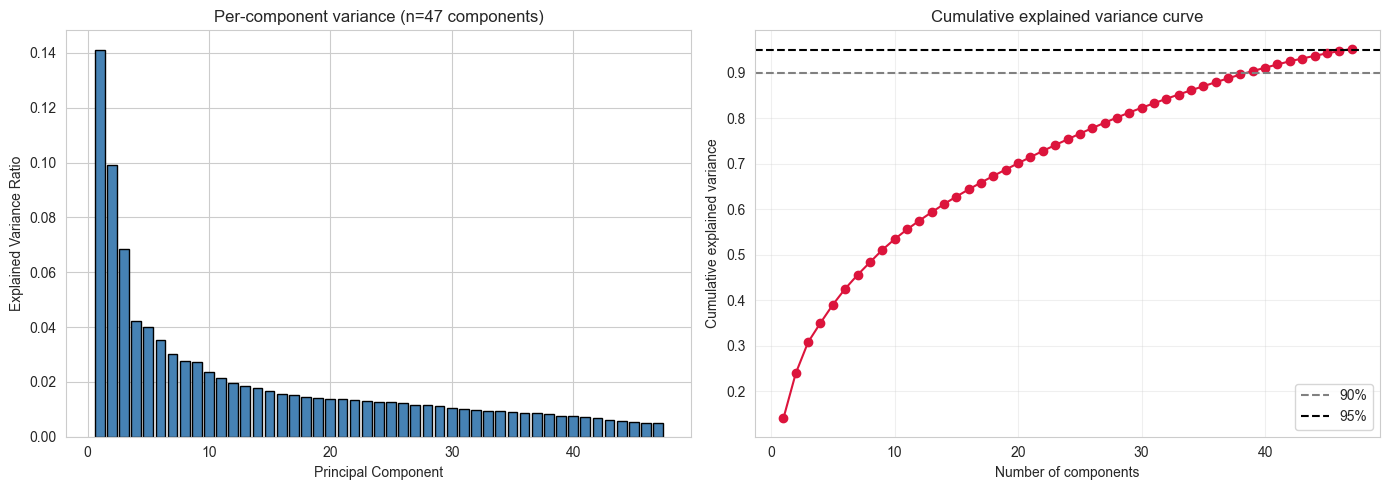

  80% variance needs 28 components
  85% variance needs 33 components
  90% variance needs 39 components
  95% variance needs 47 components


In [20]:
pca = preprocessing_pipeline.named_steps['pca']
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: per-component variance
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'Per-component variance (n={len(explained)} components)')

# right: cumulative variance
axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='crimson')
axes[1].axhline(0.90, color='gray', linestyle='--', label='90%')
axes[1].axhline(0.95, color='black', linestyle='--', label='95%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# report how many components for each variance threshold
for threshold in [0.80, 0.85, 0.90, 0.95]:
    n = np.searchsorted(cumulative, threshold) + 1
    print(f"  {threshold*100:.0f}% variance needs {n} components")

### Sanity checks

**Spec compliance check (Section 3.1):** the cap is 50 features for clustering. After PCA, the pipeline outputs **47 components**, which is what KMeans actually sees. Also checking no NaN/Inf and that the pipeline is reproducible.

In [21]:
# === SPEC COMPLIANCE CHECK: feature count must be ≤ 50 (Section 3.1) ===
n_components = X_transformed.shape[1]
print('=' * 60)
print(f'  FEATURE COUNT: {n_components} components (spec cap: 50)')
if n_components <= 50:
    print(f'  STATUS: [OK] under the cap by {50 - n_components}')
else:
    print(f'  STATUS: [FAIL] exceeds cap by {n_components - 50}')
print('=' * 60)

# other sanity checks
has_nan = np.isnan(X_transformed).any()
has_inf = np.isinf(X_transformed).any()
print(f'\n[OK] No NaN/Inf' if not (has_nan or has_inf)
      else f'[FAIL] NaN: {has_nan}, Inf: {has_inf}')

# transform twice and check we get the same thing
X_transformed_again = preprocessing_pipeline.transform(X_original)
reproducible = np.allclose(X_transformed, X_transformed_again)
print(f'[OK] Reproducible' if reproducible else f'[FAIL] not reproducible')

  FEATURE COUNT: 47 components (spec cap: 50)
  STATUS: [OK] under the cap by 3

[OK] No NaN/Inf
[OK] Reproducible


### Save the pipeline

In [22]:
joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.joblib')
print('Saved: preprocessing_pipeline.joblib')

# reload and check it round-trips correctly
loaded = joblib.load('preprocessing_pipeline.joblib')
X_check = loaded.transform(X_original)
print(f'[OK] Reload test passed: output shape {X_check.shape}')

Saved: preprocessing_pipeline.joblib
[OK] Reload test passed: output shape (5807, 47)


---
## Section 3.2 — Cluster Companies into Subgroups

Use KMeans with k=8. Spec allows k between team_size (4) and 2×team_size (8), and we picked the upper end so we have more flexibility in how to divide up the work.

### Fit KMeans

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K = 8  # spec allows up to 2x team size, we have 4 members
kmeans = KMeans(
    n_clusters=K,
    n_init=20,            # 20 random restarts, keep best
    max_iter=500,
    random_state=42
)
cluster_labels = kmeans.fit_predict(X_transformed)

print(f"KMeans fit complete")
print(f"Number of clusters: {K}")
print(f"Inertia (within-cluster SSE): {kmeans.inertia_:.1f}")
print(f"Iterations to converge: {kmeans.n_iter_}")

KMeans fit complete
Number of clusters: 8
Inertia (within-cluster SSE): 306805.4
Iterations to converge: 34


### Cluster composition

How many companies and bankruptcies per cluster. This is what feeds into Table 3 of the report.

In [24]:
# Build cluster composition dataframe
composition = pd.DataFrame({
    'cluster_id':   range(K),
    'n_companies':  [(cluster_labels == c).sum() for c in range(K)],
    'n_bankrupt':   [((cluster_labels == c) & (y == 1)).sum() for c in range(K)],
    'n_healthy':    [((cluster_labels == c) & (y == 0)).sum() for c in range(K)],
})
composition['bankrupt_pct'] = (composition['n_bankrupt'] / composition['n_companies'] * 100).round(2)
composition = composition.sort_values('bankrupt_pct', ascending=False).reset_index(drop=True)

print("CLUSTER COMPOSITION (sorted by bankruptcy %)\n")
print(composition.to_string(index=False))
print(f"\nTotal companies: {composition['n_companies'].sum()}  (should be 5807)")
print(f"Total bankruptcies: {composition['n_bankrupt'].sum()}  (should be 198)")

CLUSTER COMPOSITION (sorted by bankruptcy %)

 cluster_id  n_companies  n_bankrupt  n_healthy  bankrupt_pct
          6            7           5          2         71.43
          2          904         101        803         11.17
          5          916          72        844          7.86
          4           33           2         31          6.06
          0          610           4        606          0.66
          3         1024           6       1018          0.59
          1         1749           8       1741          0.46
          7          564           0        564          0.00

Total companies: 5807  (should be 5807)
Total bankruptcies: 198  (should be 198)


### Constant-prediction clusters

If a cluster has only one class (all bankrupt or all healthy), the spec says we can use a constant predictor instead of a real model.

In [25]:
all_healthy  = composition[composition['n_bankrupt'] == 0]
all_bankrupt = composition[composition['n_healthy'] == 0]
mixed        = composition[(composition['n_bankrupt'] > 0) & (composition['n_healthy'] > 0)]

print(f"Clusters that are 100% healthy   (const predictor ĥ=0): {len(all_healthy)}")
print(f"Clusters that are 100% bankrupt  (const predictor ĥ=1): {len(all_bankrupt)}")
print(f"Mixed clusters needing a real model: {len(mixed)}")

if len(all_healthy) > 0:
    print(f"\nAll-healthy cluster IDs: {all_healthy['cluster_id'].tolist()}")
if len(all_bankrupt) > 0:
    print(f"All-bankrupt cluster IDs: {all_bankrupt['cluster_id'].tolist()}")

# make sure each team member can be assigned at least one cluster
team_size = 4   # update if your team size differs
if len(mixed) < team_size:
    print(f"\n[!] WARNING: only {len(mixed)} mixed clusters for a {team_size}-person team.")
    print(f"    Spec says to increment k and retry until each member has at least one cluster.")
else:
    print(f"\n[OK] {len(mixed)} mixed clusters available for {team_size} team members.")

Clusters that are 100% healthy   (const predictor ĥ=0): 1
Clusters that are 100% bankrupt  (const predictor ĥ=1): 0
Mixed clusters needing a real model: 7

All-healthy cluster IDs: [7]

[OK] 7 mixed clusters available for 4 team members.


### Visualize cluster sizes and bankruptcy rates

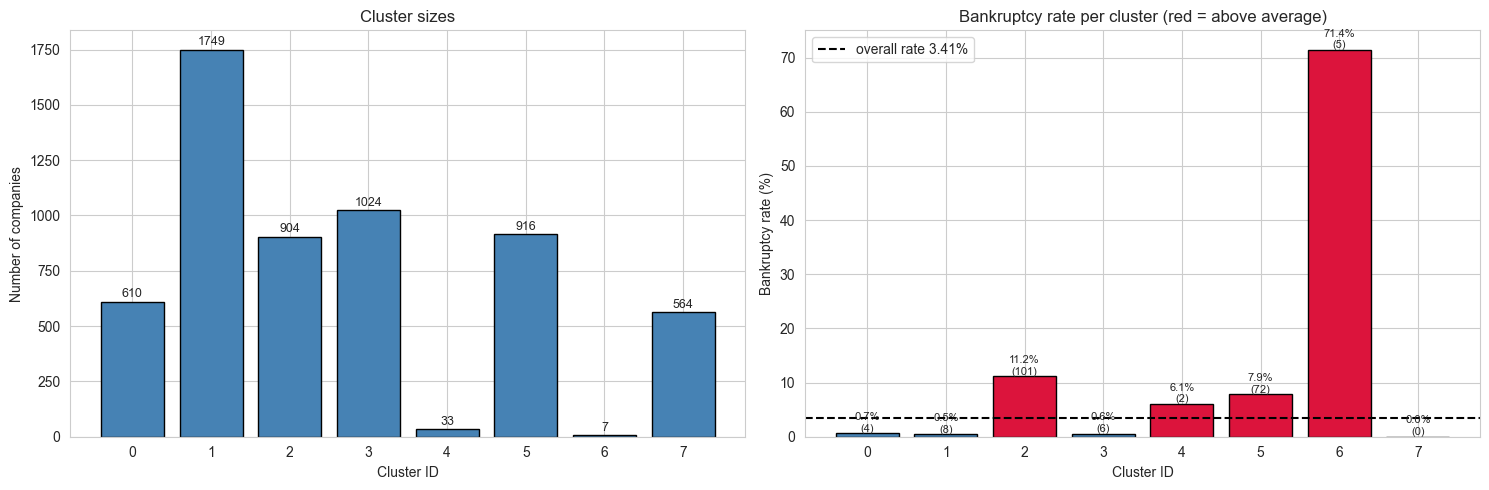

In [26]:
# resort by cluster_id for plotting
comp_by_id = composition.sort_values('cluster_id').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: cluster sizes
bars = axes[0].bar(comp_by_id['cluster_id'], comp_by_id['n_companies'],
                    color='steelblue', edgecolor='black')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of companies')
axes[0].set_title('Cluster sizes')
for bar, v in zip(bars, comp_by_id['n_companies']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20, str(v),
                 ha='center', fontsize=9)

# right: bankruptcy rate per cluster
colors = ['crimson' if p > 3.41 else 'steelblue' for p in comp_by_id['bankrupt_pct']]
bars = axes[1].bar(comp_by_id['cluster_id'], comp_by_id['bankrupt_pct'],
                    color=colors, edgecolor='black')
axes[1].axhline(3.41, color='black', linestyle='--', label='overall rate 3.41%')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Bankruptcy rate (%)')
axes[1].set_title('Bankruptcy rate per cluster (red = above average)')
axes[1].legend()
for bar, v, n in zip(bars, comp_by_id['bankrupt_pct'], comp_by_id['n_bankrupt']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%\n({n})',
                 ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 2D visualization (PC1 vs PC2)

Caveat: this only shows 2 of 47 dimensions, so things that look overlapping in 2D might be well separated in higher dimensions.

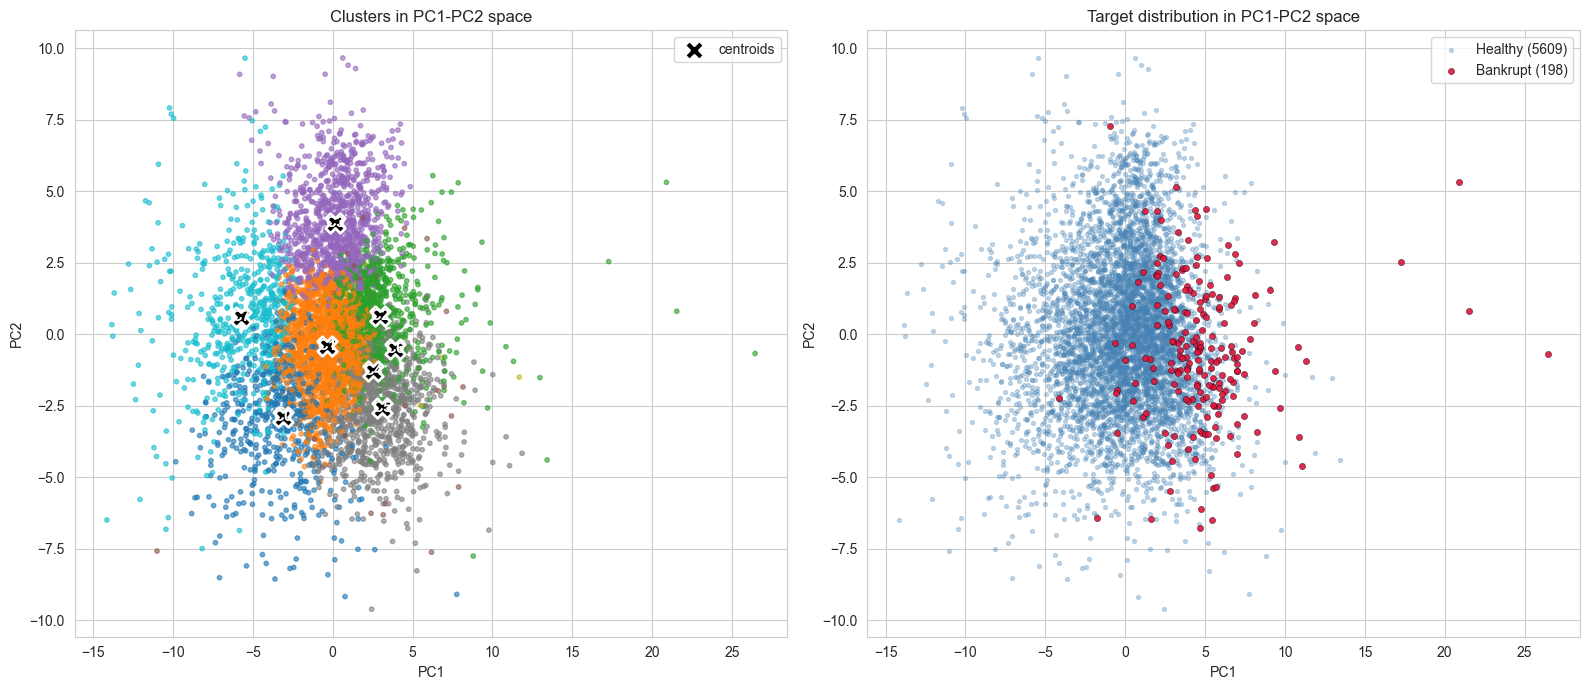

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left: colored by cluster
scatter = axes[0].scatter(X_transformed[:, 0], X_transformed[:, 1],
                           c=cluster_labels, cmap='tab10', s=10, alpha=0.6)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Clusters in PC1-PC2 space')
# plot centroid markers
centroids_2d = kmeans.cluster_centers_[:, :2]
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=200, edgecolor='white', linewidth=2,
                label='centroids')
for i, (x, z) in enumerate(centroids_2d):
    axes[0].annotate(f'C{i}', (x, z), fontsize=11, fontweight='bold',
                     color='white', ha='center', va='center')
axes[0].legend()

# right: healthy vs bankrupt
healthy_mask  = y == 0
bankrupt_mask = y == 1
axes[1].scatter(X_transformed[healthy_mask, 0], X_transformed[healthy_mask, 1],
                c='steelblue', s=8, alpha=0.3, label=f'Healthy ({healthy_mask.sum()})')
axes[1].scatter(X_transformed[bankrupt_mask, 0], X_transformed[bankrupt_mask, 1],
                c='crimson', s=20, alpha=0.9, label=f'Bankrupt ({bankrupt_mask.sum()})',
                edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Target distribution in PC1-PC2 space')
axes[1].legend()

plt.tight_layout()
plt.show()

### Silhouette score

Silhouette measures cluster separation (-1 to +1, higher is better). For high-dim messy data like ours, anything > 0.1 is usually acceptable.

In [28]:
# subsample to 2000 for speed
from sklearn.utils import resample

sample_idx = resample(np.arange(len(cluster_labels)),
                      n_samples=min(2000, len(cluster_labels)),
                      replace=False, random_state=RANDOM_STATE)

sil_score = silhouette_score(X_transformed[sample_idx],
                              cluster_labels[sample_idx],
                              random_state=RANDOM_STATE)
print(f"Silhouette score (sample of 2000): {sil_score:.3f}")

if sil_score > 0.25:
    print("  → Good cluster separation")
elif sil_score > 0.10:
    print("  → Acceptable cluster separation for high-dimensional real-world data")
else:
    print("  → Weak separation — clusters overlap heavily; consider different k or method")

Silhouette score (sample of 2000): 0.065
  → Weak separation — clusters overlap heavily; consider different k or method


Score is low but that's expected — the goal here isn't tight geometric clusters, it's to separate companies by bankruptcy risk. The composition table above shows that worked: C2 has 11% bankruptcy rate, C6 has 71%, C7 has 0%.

### Characterize each cluster

Clustering ran on PCA components which aren't interpretable. To describe clusters in financial terms, computing per-cluster means on the original (pre-PCA) features and converting to z-scores against the population mean.

In [29]:
# attach cluster labels back to the original features
X_with_clusters = X_pruned.copy()
X_with_clusters['cluster'] = cluster_labels
X_with_clusters['bankrupt'] = y.values

# per-cluster means of each feature
overall_means = X_pruned.mean()
cluster_means = X_with_clusters.groupby('cluster')[X_pruned.columns].mean()

# convert to z-scores: (cluster_mean - overall_mean) / overall_std
overall_stds = X_pruned.std().replace(0, 1)  # avoid division by zero
cluster_zscores = (cluster_means - overall_means) / overall_stds

print("Top 5 distinguishing features per cluster (by absolute z-score from population mean):\n")
for c in range(K):
    n = (cluster_labels == c).sum()
    n_bk = ((cluster_labels == c) & (y == 1)).sum()
    pct = n_bk / n * 100
    top_features = cluster_zscores.loc[c].abs().sort_values(ascending=False).head(5)
    print(f"\n{'='*70}")
    print(f"CLUSTER {c}  |  n={n}  bankrupt={n_bk} ({pct:.1f}%)")
    print(f"{'='*70}")
    for feat in top_features.index:
        z = cluster_zscores.loc[c, feat]
        direction = "ABOVE" if z > 0 else "BELOW"
        print(f"  {feat[:55]:<55} {direction} avg by {abs(z):.2f} std")

Top 5 distinguishing features per cluster (by absolute z-score from population mean):


CLUSTER 0  |  n=610  bankrupt=4 (0.7%)
  Equity to Liability                                     ABOVE avg by 1.32 std
  Debt ratio %                                            BELOW avg by 1.22 std
  Working Capital to Total Assets                         ABOVE avg by 1.14 std
  Current Liability to Assets                             BELOW avg by 1.00 std
  Cash/Total Assets                                       ABOVE avg by 0.83 std

CLUSTER 1  |  n=1749  bankrupt=8 (0.5%)
  Current Assets/Total Assets                             BELOW avg by 0.40 std
  Current Liability to Assets                             BELOW avg by 0.38 std
  Debt ratio %                                            BELOW avg by 0.33 std
  Retained Earnings to Total Assets                       ABOVE avg by 0.33 std
  Quick Assets/Total Assets                               BELOW avg by 0.32 std

CLUSTER 2  |  n=904  bankrupt=1

### Heatmap of cluster profiles

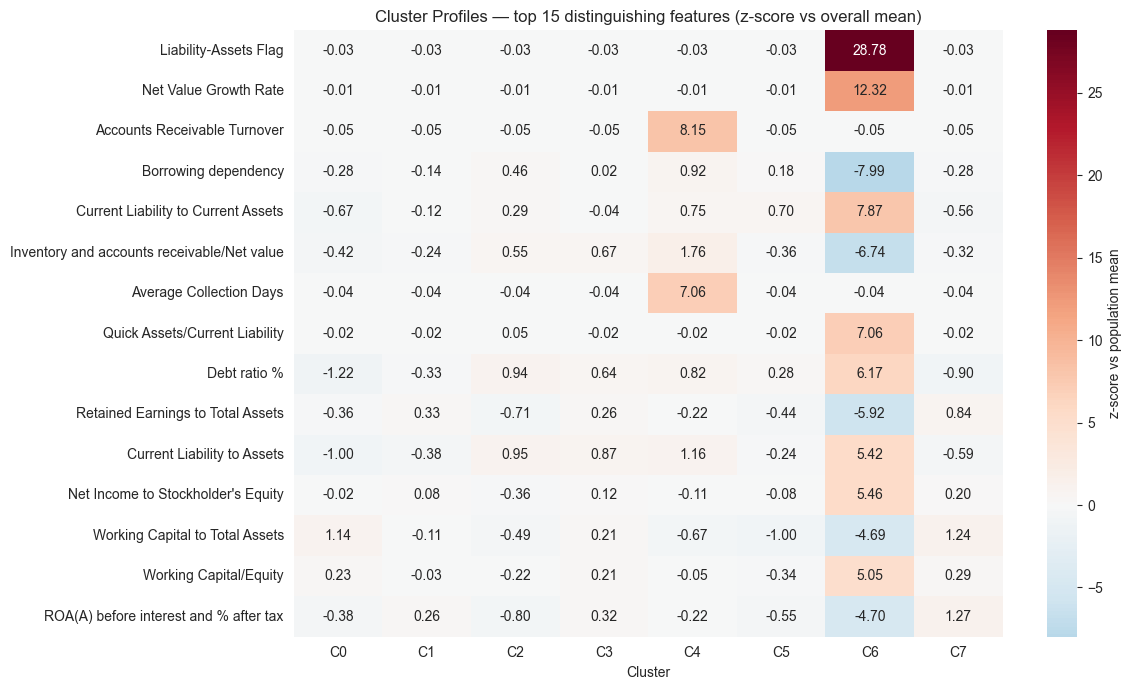

In [30]:
# pick the 15 features that vary most across clusters
feature_discriminating_power = cluster_zscores.var(axis=0).sort_values(ascending=False)
top_discriminating = feature_discriminating_power.head(15).index.tolist()

# plot heatmap
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cluster_zscores[top_discriminating].T,
            cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': 'z-score vs population mean'}, ax=ax,
            xticklabels=[f'C{i}' for i in range(K)],
            yticklabels=[f[:45] for f in top_discriminating])
ax.set_title('Cluster Profiles — top 15 distinguishing features (z-score vs overall mean)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

Columns are clusters, rows are features. Red = above population mean, blue = below. Useful for writing up the report — e.g. Cluster 2 has high debt ratios and low ROA (classic distressed firms, matches its 11% bankruptcy rate).

### Save the KMeans model

In [31]:
joblib.dump(kmeans, 'kmeans_model.joblib')
print('Saved: kmeans_model.joblib')

Saved: kmeans_model.joblib


### Export per-cluster CSVs

Each teammate will use their assigned cluster's CSV to train their stacking model in Phase 2.

In [32]:
import os

OUTPUT_DIR = 'clusters'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# attach cluster labels to the raw training data so each teammate has access
# to all original features (they can pick which to use in Phase 2)
df_with_cluster = df.copy()
df_with_cluster['Cluster'] = cluster_labels

summary_rows = []
for cid in sorted(df_with_cluster['Cluster'].unique()):
    cluster_df = df_with_cluster[df_with_cluster['Cluster'] == cid]
    path = os.path.join(OUTPUT_DIR, f'cluster_{cid}.csv')
    cluster_df.to_csv(path, index=False)

    n_total    = len(cluster_df)
    n_bankrupt = int((cluster_df['Bankrupt?'] == 1).sum())
    summary_rows.append({
        'Cluster':        f'C{cid}',
        'File':           os.path.basename(path),
        'N Companies':    n_total,
        'N Bankrupt (1)': n_bankrupt,
        'N Healthy (0)':  n_total - n_bankrupt,
        'Bankrupt %':     round(n_bankrupt / n_total * 100, 2)
    })

summary = pd.DataFrame(summary_rows)

# sanity checks
assert summary['N Companies'].sum() == len(df), 'row count mismatch'
assert summary['N Bankrupt (1)'].sum() == 198, 'should be 198 bankrupts total'

print(f'Saved {len(summary)} cluster files to: {OUTPUT_DIR}\n')
print(summary.to_string(index=False))

Saved 8 cluster files to: clusters

Cluster          File  N Companies  N Bankrupt (1)  N Healthy (0)  Bankrupt %
     C0 cluster_0.csv          610               4            606        0.66
     C1 cluster_1.csv         1749               8           1741        0.46
     C2 cluster_2.csv          904             101            803       11.17
     C3 cluster_3.csv         1024               6           1018        0.59
     C4 cluster_4.csv           33               2             31        6.06
     C5 cluster_5.csv          916              72            844        7.86
     C6 cluster_6.csv            7               5              2       71.43
     C7 cluster_7.csv          564               0            564        0.00


---
## Section 3.3.1 — Cluster-ID Routing Classifier

Classifier that predicts which cluster a new company goes to. At test time this routes each test company to the right subgroup model.

Using Logistic Regression on the raw (pre-PCA) features. We could use PCA components but then the feature importances would say things like "PC3 matters" — not useful for the report. Raw features keep the financial ratios interpretable.

### Fit the classifier

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SKPipeline

X_for_classifier = X.copy()      # 94 raw features (post zero-var drop)
y_cluster        = cluster_labels  # the 8 cluster labels we just made

# StandardScaler then LR (LR needs scaled features)
cluster_clf = SKPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=2000, solver='lbfgs',
                                  random_state=RANDOM_STATE))
])
cluster_clf.fit(X_for_classifier, y_cluster)

train_acc = cluster_clf.score(X_for_classifier, y_cluster)
print(f'Input shape:       {X_for_classifier.shape}')
print(f'Number of classes: {len(np.unique(y_cluster))}')
print(f'Training accuracy: {train_acc:.4f}')

Input shape:       (5807, 94)
Number of classes: 8
Training accuracy: 0.9416


### Held-out test accuracy

Stratified 80/20 split on the raw features, fit LR on 80% and evaluate on the 20% held-out. Stratified so cluster proportions match in both sets — important here because C6 has only 7 companies and could end up missing from one side otherwise.

In [34]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_for_classifier, y_cluster,
    test_size=0.2,
    stratify=y_cluster,
    random_state=RANDOM_STATE,
)

split_clf = SKPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=2000, solver='lbfgs',
                                  random_state=RANDOM_STATE))
])
split_clf.fit(X_tr, y_tr)

split_train_acc = split_clf.score(X_tr, y_tr)
split_test_acc  = split_clf.score(X_te, y_te)

print('=' * 60)
print(f'  ROUTING CLASSIFIER TEST ACCURACY (80/20 held-out split)')
print(f'  Train: {split_train_acc:.4f}   Test: {split_test_acc:.4f}')
print('=' * 60)

  ROUTING CLASSIFIER TEST ACCURACY (80/20 held-out split)
  Train: 0.9479   Test: 0.9303


### Cross-validation (test-set accuracy estimate)

Training accuracy can overfit, so reporting 5-fold CV here as the held-out estimate of how the routing classifier will perform on test data. **This is the routing test accuracy that matters for generalization.**

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=RANDOM_STATE)
)
cv_scores = cross_val_score(cv_pipeline, X_for_classifier, y_cluster,
                            cv=cv, scoring='accuracy', n_jobs=-1)

print('=' * 60)
print(f'  ROUTING CLASSIFIER TEST ACCURACY (5-fold CV)')
print(f'  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 60)
print(f'\nPer-fold scores: {[f"{s:.4f}" for s in cv_scores]}')

  ROUTING CLASSIFIER TEST ACCURACY (5-fold CV)
  0.9201 ± 0.0089

Per-fold scores: ['0.9355', '0.9174', '0.9078', '0.9208', '0.9190']


### Feature importances

Spec says: *"Identify the features that play important roles in this prediction."* Multiclass LR has one coefficient vector per cluster (8 vectors of length 94). Taking mean |coef| across clusters gives a single importance score per feature.

TOP 15 FEATURES DRIVING CLUSTER ROUTING

                                 feature  importance
                    Total Asset Turnover       1.287
             Current Liability to Assets       1.095
         Working Capital to Total Assets       1.091
     Current Liability to Current Assets       1.083
               Quick Assets/Total Assets       1.073
                            Debt ratio %       0.943
                        Net worth/Assets       0.943
    Long-term fund suitability ratio (A)       0.917
         Net Worth Turnover Rate (times)       0.899
              Net Income to Total Assets       0.826
       Retained Earnings to Total Assets       0.814
                       Cash/Total Assets       0.799
                     Equity to Liability       0.722
Per Share Net profit before tax (Yuan ¥)       0.714
  ROA(A) before interest and % after tax       0.678


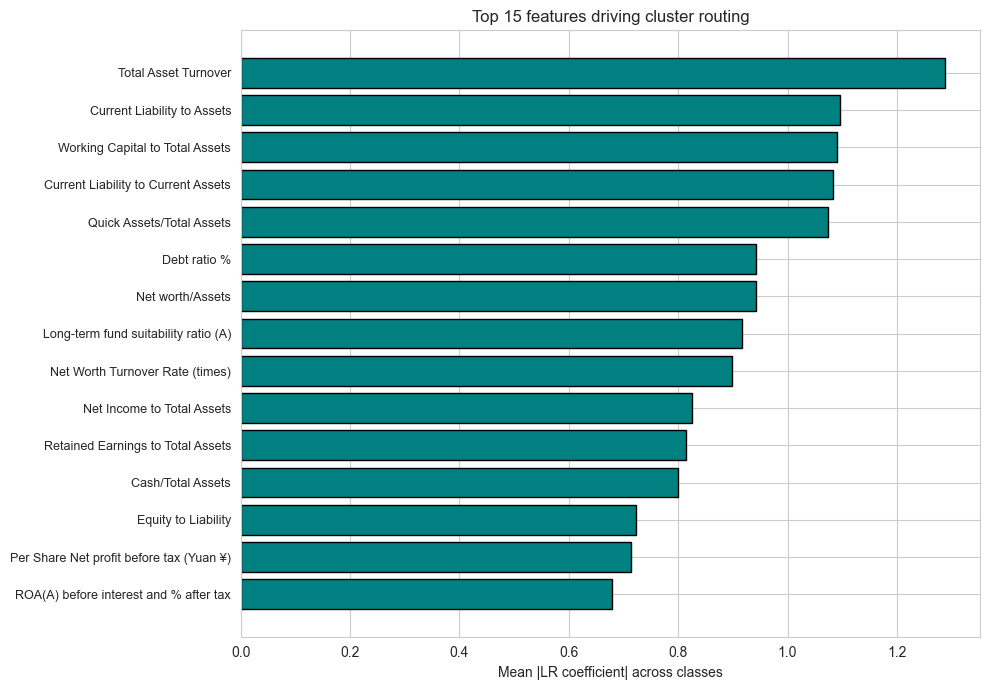

In [36]:
abs_coefs = np.abs(cluster_clf.named_steps['clf'].coef_)  # shape (8, 94)
importances = (pd.DataFrame({
    'feature':    X_for_classifier.columns,
    'importance': abs_coefs.mean(axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True))

print('TOP 15 FEATURES DRIVING CLUSTER ROUTING\n')
print(importances.head(15).round(3).to_string(index=False))

# bar chart
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importances.head(15).iloc[::-1]
ax.barh(range(len(top15)), top15['importance'], color='teal', edgecolor='black')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f[:42] for f in top15['feature']], fontsize=9)
ax.set_xlabel('Mean |LR coefficient| across classes')
ax.set_title('Top 15 features driving cluster routing')
plt.tight_layout()
plt.show()

### Save the classifier

In [37]:
joblib.dump(cluster_clf, 'cluster_id_classifier.joblib')
print('Saved: cluster_id_classifier.joblib')

Saved: cluster_id_classifier.joblib


In [42]:
!jupyter nbconvert --to script khush_559_Phase1_clean.ipynb

[NbConvertApp] Converting notebook khush_559_Phase1_clean.ipynb to script
[NbConvertApp] Writing 32252 bytes to khush_559_Phase1_clean.py
